# Analisis del Censo 2022 de Salta

## Exploracion, transformacion y modelado analitico de datos censales

Este notebook documenta un flujo reproducible para transformar datos del **Censo Nacional de Poblacion, Hogares y Viviendas 2022** de la provincia de Salta en un conjunto de datos analitico.

El proyecto combina:

- exploracion y control de calidad;
- normalizacion de variables y categorias;
- construccion de un modelo dimensional tipo estrella;
- analisis de poblacion y educacion;
- integracion con informacion geografica de radios censales;
- generacion de mapas tematicos;
- consultas analiticas sobre PostgreSQL/PostGIS;
- construccion de una distribucion demografica derivada a partir de los datos disponibles.

> **Alcance:** los valores observados se mantienen separados de cualquier indicador calculado o estimado. En particular, la distribucion por sexo dentro de grupos etarios se presenta como una **estimacion derivada**, no como un dato censal observado directamente en esta transformacion.

## 1. Configuracion y dependencias

El notebook esta pensado para ejecutarse desde la raiz del proyecto. Las rutas de entrada y salida se concentran en una unica seccion para facilitar su adaptacion a otro entorno.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

from IPython.display import display
from dotenv import load_dotenv

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

ROOT = Path(".")
CENSUS_DIR = ROOT / "66-salta-2022"
OUTPUT_DIR = ROOT / "censo_diseno_final"
MAP_DIR = ROOT / "mapas_generados"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

CENSUS_FILES = {
    "hogar": CENSUS_DIR / "66-salta-2022-hogar.csv",
    "persona": CENSUS_DIR / "66-salta-2022-persona.csv",
    "vivienda": CENSUS_DIR / "66-salta-2022-vivienda.csv",
    "diccionario": CENSUS_DIR / "diccionario-variables.csv",
}

RADIOS_FILE = ROOT / "radios2022c_vivVacias.gpkg"
RADIOS_LAYER = "radios2022c_vivvacias"

EXPECTED_POPULATION = 1_434_225

## 2. Carga de los datos

Se cargan las tres entidades censales disponibles —hogar, persona y vivienda— junto con el diccionario de variables. Antes de transformar los datos se conserva una copia de las estructuras originales para que las etapas posteriores puedan auditarse.

In [2]:
missing_files = [path for path in CENSUS_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "No se encontraron los siguientes archivos de entrada:\n"
        + "\n".join(f"- {path}" for path in missing_files)
    )

df_hogar = pd.read_csv(CENSUS_FILES["hogar"])
df_persona = pd.read_csv(CENSUS_FILES["persona"])
df_vivienda = pd.read_csv(CENSUS_FILES["vivienda"])
df_diccionario = pd.read_csv(CENSUS_FILES["diccionario"])

datasets = {
    "Hogar": df_hogar,
    "Persona": df_persona,
    "Vivienda": df_vivienda,
    "Diccionario": df_diccionario,
}

pd.DataFrame(
    {
        "dataset": datasets.keys(),
        "filas": [df.shape[0] for df in datasets.values()],
        "columnas": [df.shape[1] for df in datasets.values()],
    }
).reset_index(drop=True)

,dataset,filas,columnas
0,Hogar,209096,11
1,Persona,567706,11
2,Vivienda,61354,11
3,Diccionario,86,5


## 3. Exploracion inicial y calidad de datos

La exploracion se centra en dimensiones que afectan directamente al modelo analitico: tipos de datos, valores nulos, duplicados y cobertura de variables.

No se eliminan registros automaticamente durante esta etapa. Las decisiones de limpieza se aplican despues de identificar que representan los registros.

In [3]:
def quality_report(df, name):
    return pd.Series(
        {
            "dataset": name,
            "filas": len(df),
            "columnas": df.shape[1],
            "duplicados": int(df.duplicated().sum()),
            "celdas_nulas": int(df.isna().sum().sum()),
            "columnas_con_nulos": int(df.isna().any().sum()),
        }
    )

quality = pd.DataFrame(
    [quality_report(df, name) for name, df in datasets.items()]
).reset_index(drop=True)

display(quality)

for name, df in datasets.items():
    nulls = (
        df.isna()
        .sum()
        .loc[lambda s: s.gt(0)]
        .sort_values(ascending=False)
        .rename("nulos")
        .to_frame()
    )
    if not nulls.empty:
        display(nulls.style.set_caption(f"Nulos detectados — {name}"))

,dataset,filas,columnas,duplicados,celdas_nulas,columnas_con_nulos
0,Hogar,209096,11,0,0,0
1,Persona,567706,11,0,0,0
2,Vivienda,61354,11,0,0,0
3,Diccionario,86,5,0,0,0


## 4. Normalizacion de codigos geograficos

Los codigos censales contienen una jerarquia geografica codificada. Se normalizan a nueve posiciones y se separan en provincia, departamento, fraccion y radio.

El objetivo es disponer de una dimension geografica estable que pueda relacionarse con las tres entidades censales y, posteriormente, con la informacion espacial.

In [4]:
DEPARTMENT_NAMES = {
    "007": "Anta",
    "014": "Cachi",
    "021": "Cafayate",
    "028": "Capital",
    "035": "Cerrillos",
    "042": "Chicoana",
    "049": "General Guemes",
    "056": "General Jose de San Martin",
    "063": "Guachipas",
    "070": "Iruya",
    "077": "La Caldera",
    "084": "La Candelaria",
    "091": "La Poma",
    "098": "La Vina",
    "105": "Los Andes",
    "112": "Metan",
    "119": "Molinos",
    "126": "Oran",
    "133": "Rivadavia",
    "140": "Rosario de la Frontera",
    "147": "Rosario de Lerma",
    "154": "San Carlos",
    "161": "Santa Victoria",
}

def normalize_code(series):
    return series.astype("string").str.zfill(9)

all_codes = pd.concat(
    [df["codigo"] for df in (df_hogar, df_persona, df_vivienda)],
    ignore_index=True,
).dropna()

all_codes = normalize_code(all_codes).drop_duplicates().sort_values()

df_geo = pd.DataFrame({"codigo": all_codes})
df_geo["cod_prov"] = df_geo["codigo"].str[:2]
df_geo["cod_dep"] = df_geo["codigo"].str[2:5]
df_geo["fraccion"] = df_geo["codigo"].str[5:7]
df_geo["radio"] = df_geo["codigo"].str[7:9]
df_geo["provincia"] = "Salta"
df_geo["departamento"] = df_geo["cod_dep"].map(DEPARTMENT_NAMES)

df_geo["id_geografia"] = np.arange(1, len(df_geo) + 1)

df_geo = df_geo[
    [
        "id_geografia",
        "codigo",
        "cod_prov",
        "provincia",
        "cod_dep",
        "departamento",
        "fraccion",
        "radio",
    ]
]

assert df_geo["codigo"].is_unique
assert df_geo["departamento"].notna().all()

display(df_geo.head())

,id_geografia,codigo,cod_prov,provincia,cod_dep,departamento,fraccion,radio
0,1,660070101,66,Salta,007,Anta,01,01
117,2,660070102,66,Salta,007,Anta,01,02
223,3,660070103,66,Salta,007,Anta,01,03
297,4,660070104,66,Salta,007,Anta,01,04
415,5,660070105,66,Salta,007,Anta,01,05


## 5. Normalizacion del diccionario de variables

El diccionario funciona como catalogo de metadatos. Se conservan unicamente las variables que realmente aparecen en los archivos censales utilizados, evitando cargar definiciones que no tienen correspondencia con los hechos analizados.

In [5]:
present_variables = pd.concat(
    [
        df_hogar["cod_variable"],
        df_persona["cod_variable"],
        df_vivienda["cod_variable"],
    ],
    ignore_index=True,
).dropna().drop_duplicates()

df_variables = (
    df_diccionario[df_diccionario["cod_variable"].isin(present_variables)]
    .sort_values("cod_variable")
    .reset_index(drop=True)
)

df_variables["id_variable"] = np.arange(1, len(df_variables) + 1)

df_variables = df_variables[
    [
        "id_variable",
        "cod_variable",
        "entidad",
        "variable",
        "descripcion",
        "tipo_variable",
    ]
]

assert df_variables["cod_variable"].is_unique
display(df_variables.head(10))

,id_variable,cod_variable,entidad,variable,descripcion,tipo_variable
0,1,HOGAR_EDUHOG,HOGAR,EDUHOG,Clima educativo del hogar,categorica
1,2,HOGAR_H10,HOGAR,H10,Material predominante de los pisos,categorica
2,3,HOGAR_H11,HOGAR,H11,Material predominante de la cubierta exterior ...,categorica
3,4,HOGAR_H13,HOGAR,H13,Tenencia de agua,categorica
4,5,HOGAR_H14,HOGAR,H14,Procedencia del agua para beber y cocinar,categorica
5,6,HOGAR_H15_17,HOGAR,H15_17,Inodoro con desacarga de agua,categorica
6,7,HOGAR_H15_17_18,HOGAR,H15_17_18,Servicio sanitario,categorica
7,8,HOGAR_H16,HOGAR,H16,Cantidad de baños,categorica
8,9,HOGAR_H18,HOGAR,H18,Desagüe del inodoro,categorica
9,10,HOGAR_H19,HOGAR,H19,Combustible usado principalmente para cocinar,categorica


## 6. Construccion de la dimension de categorias

Las categorias se deduplican por variable y codigo de categoria. La clave artificial `id_categoria` permite desacoplar las tablas de hechos de los codigos originales y simplifica las relaciones del modelo estrella.

In [6]:
df_universo = pd.concat(
    [df_hogar, df_persona, df_vivienda],
    ignore_index=True,
)

df_categorias = (
    df_universo[["cod_variable", "cod_categoria", "categoria"]]
    .drop_duplicates()
    .merge(
        df_variables[["id_variable", "cod_variable"]],
        on="cod_variable",
        how="left",
        validate="many_to_one",
    )
    .sort_values(["cod_variable", "cod_categoria"])
    .reset_index(drop=True)
)

df_categorias["id_categoria"] = np.arange(1, len(df_categorias) + 1)

df_categorias = df_categorias[
    ["id_categoria", "id_variable", "cod_categoria", "categoria"]
]

assert df_categorias["id_variable"].notna().all()
assert df_categorias["id_categoria"].is_unique

category_map = (
    df_categorias
    .merge(df_variables[["id_variable", "cod_variable"]], on="id_variable")
    .set_index(["cod_variable", "cod_categoria"])["id_categoria"]
    .to_dict()
)

display(df_categorias.head(10))

,id_categoria,id_variable,cod_categoria,categoria
0,1,1,1,Muy bajo
1,2,1,2,Bajo
2,3,1,3,Medio
3,4,1,4,Alto
4,5,1,5,Muy alto
5,6,1,9,No corresponde
6,7,2,1,"Cerámica, mosaico, baldosa, alfombra, madera, ..."
7,8,2,2,"Carpeta, contrapiso o ladrillo fijo"
8,9,2,3,Tierra o ladrillo suelto
9,10,2,4,Otro material


## 7. Transformacion de tablas de hechos

Cada entidad se transforma a una estructura comun:

`codigo geografico → categoria → cantidad`

Los registros que no puedan asociarse a una categoria conocida no se eliminan silenciosamente: se cuantifican y la transformacion falla si aparecen inconsistencias.

In [7]:
def build_fact_table(df, entity_name):
    fact = df[["codigo", "cod_variable", "cod_categoria", "cantidad"]].copy()
    fact["codigo"] = normalize_code(fact["codigo"])
    fact["id_categoria"] = [
        category_map.get((variable, category))
        for variable, category in zip(
            fact["cod_variable"], fact["cod_categoria"]
        )
    ]

    missing_categories = int(fact["id_categoria"].isna().sum())
    if missing_categories:
        raise ValueError(
            f"{entity_name}: {missing_categories:,} registros no pudieron "
            "asociarse a una categoria."
        )

    fact["id_categoria"] = fact["id_categoria"].astype("int64")
    fact["cantidad"] = pd.to_numeric(fact["cantidad"], errors="raise")

    return fact[["codigo", "id_categoria", "cantidad"]]

df_hogar_h = build_fact_table(df_hogar, "hogar")
df_persona_h = build_fact_table(df_persona, "persona")
df_vivienda_h = build_fact_table(df_vivienda, "vivienda")

fact_summary = pd.DataFrame(
    {
        "tabla": ["fact_hogar", "fact_persona", "fact_vivienda"],
        "filas": [len(df_hogar_h), len(df_persona_h), len(df_vivienda_h)],
        "suma_cantidad": [
            df_hogar_h["cantidad"].sum(),
            df_persona_h["cantidad"].sum(),
            df_vivienda_h["cantidad"].sum(),
        ],
    }
)

display(fact_summary)

,tabla,filas,suma_cantidad
0,fact_hogar,209096,12408779
1,fact_persona,567706,31513975
2,fact_vivienda,61354,5183537


## 8. Persistencia del modelo analitico

La transformacion se materializa en CSV para separar claramente la etapa de preparacion de datos de la etapa de analisis. Estos archivos tambien pueden utilizarse como artefactos intermedios para cargar el modelo en PostgreSQL.

In [8]:
tables_to_export = {
    "geografia.csv": df_geo,
    "variables.csv": df_variables,
    "categorias.csv": df_categorias,
    "hogar.csv": df_hogar_h,
    "persona.csv": df_persona_h,
    "vivienda.csv": df_vivienda_h,
}

for filename, dataframe in tables_to_export.items():
    dataframe.to_csv(OUTPUT_DIR / filename, index=False)

export_summary = pd.DataFrame(
    {
        "archivo": list(tables_to_export),
        "filas": [len(df) for df in tables_to_export.values()],
    }
)

display(export_summary)

,archivo,filas
0,geografia.csv,1829
1,variables.csv,76
2,categorias.csv,1102
3,hogar.csv,209096
4,persona.csv,567706
5,vivienda.csv,61354


## 9. Validaciones de consistencia

Antes de avanzar al analisis se comprueba que las relaciones fundamentales del modelo esten completas y que la poblacion total coincida con el valor de control definido para la provincia.

Estas validaciones convierten supuestos implicitos en controles reproducibles.

In [9]:
df_persona_model = (
    df_persona_h
    .merge(df_categorias, on="id_categoria", how="inner", validate="many_to_one")
    .merge(df_variables, on="id_variable", how="inner", validate="many_to_one")
)

population_control = (
    df_persona_model.loc[
        df_persona_model["cod_variable"].eq("PERSONA_P02"),
        "cantidad",
    ]
    .sum()
)

assert population_control == EXPECTED_POPULATION

referential_checks = {
    "categorias_sin_variable": int(df_categorias["id_variable"].isna().sum()),
    "geografias_sin_departamento": int(df_geo["departamento"].isna().sum()),
    "poblacion_observada": int(population_control),
}

display(pd.Series(referential_checks, name="valor"))

categorias_sin_variable              0
geografias_sin_departamento          0
poblacion_observada            1434225
Name: valor, dtype: int64

# 10. Analisis exploratorio

## Poblacion por departamento

La poblacion se agrega desde el nivel de radio censal hasta departamento. El ordenamiento permite identificar la concentracion territorial de poblacion sin alterar los datos originales.

In [10]:
population = df_persona_model[
    df_persona_model["cod_variable"].eq("PERSONA_P02")
].copy()

population_by_department = (
    population
    .merge(
        df_geo[["codigo", "departamento"]],
        on="codigo",
        how="inner",
        validate="many_to_one",
    )
    .groupby("departamento", as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "poblacion"})
    .sort_values("poblacion", ascending=False)
)

population_by_department["participacion_pct"] = (
    population_by_department["poblacion"] / population_control * 100
)

display(population_by_department)

,departamento,poblacion,participacion_pct
3,Capital,624003,43.51
7,General Jose de San Martin,177448,12.37
17,Oran,159715,11.14
0,Anta,69442,4.84
6,General Guemes,55746,3.89
4,Cerrillos,55713,3.88
19,Rosario de Lerma,50961,3.55
15,Metan,48028,3.35
18,Rivadavia,38062,2.65
20,Rosario de la Frontera,33750,2.35


## Educacion: universitario completo

Se identifica la categoria correspondiente a estudios universitarios completos a partir de `PERSONA_MNI` y se agrega por departamento.

El indicador se mantiene como una medida absoluta; no se interpreta como tasa hasta definir explicitamente un denominador poblacional adecuado.

In [11]:
university = df_persona_model[
    (df_persona_model["cod_variable"] == "PERSONA_MNI")
    & (df_persona_model["cod_categoria"] == 9)
].copy()

university_total = int(university["cantidad"].sum())

university_by_department = (
    university
    .merge(
        df_geo[["codigo", "departamento"]],
        on="codigo",
        how="inner",
        validate="many_to_one",
    )
    .groupby("departamento", as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "universitario_completo"})
    .sort_values("universitario_completo", ascending=False)
)

display(pd.DataFrame({"indicador": ["Universitario completo"], "personas": [university_total]}))
display(university_by_department)

,indicador,personas
0,Universitario completo,42487


,departamento,universitario_completo
3,Capital,30022
7,General Jose de San Martin,2380
17,Oran,2063
15,Metan,1248
19,Rosario de Lerma,1127
4,Cerrillos,1051
10,La Caldera,932
6,General Guemes,769
0,Anta,748
20,Rosario de la Frontera,584


## Distribucion por sexo

La variable `PERSONA_P02` se utiliza para observar la distribucion global por categoria. Este resultado representa el dato censal disponible y no debe confundirse con la distribucion estimada por edad que se construira mas adelante.

In [12]:
sex_distribution = (
    population
    .groupby("categoria", as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "personas"})
)

sex_distribution["participacion_pct"] = (
    sex_distribution["personas"] / population_control * 100
)

display(sex_distribution)

,categoria,personas,participacion_pct
0,Mujer / Femenino,737383,51.41
1,Varón / Masculino,696842,48.59


# 11. Integracion espacial

Se incorpora la geometria de los radios censales desde el GeoPackage. La geometria se utiliza unicamente para analisis espacial y visualizacion; los datos estadisticos continuan siendo la fuente de verdad de las cantidades censales.

In [13]:
if not RADIOS_FILE.exists():
    raise FileNotFoundError(f"No se encontro la capa espacial: {RADIOS_FILE}")

gdf_radios = gpd.read_file(
    RADIOS_FILE,
    layer=RADIOS_LAYER,
    engine="pyogrio",
)

gdf_radios["CRO"] = normalize_code(gdf_radios["CRO"])

gdf_radios = gdf_radios.drop_duplicates(subset=['CRO'], keep='first')

gdf_radios = gdf_radios.merge(
    df_geo,
    left_on="CRO",
    right_on="codigo",
    how="inner",
    validate="one_to_one",
)

if gdf_radios.crs != "EPSG:4326":
    gdf_radios = gdf_radios.to_crs("EPSG:4326")

population_by_radio = (
    population.groupby("codigo", as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "poblacion"})
)

university_by_radio = (
    university.groupby("codigo", as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "universitario_completo"})
)

gdf_analysis = (
    gdf_radios
    .merge(population_by_radio, on="codigo", how="left")
    .merge(university_by_radio, on="codigo", how="left")
)

for column in ["poblacion", "universitario_completo"]:
    gdf_analysis[column] = gdf_analysis[column].fillna(0).astype(int)

display(
    gdf_analysis[
        ["codigo", "departamento", "fraccion", "radio", "poblacion", "universitario_completo", "geometry"]
    ].head()
)

,codigo,departamento,fraccion,radio,poblacion,universitario_completo,geometry
0,660560807,General Jose de San Martin,08,07,1123,33,"MULTIPOLYGON (((-63.68744 -22.04705, -63.68649..."
1,660560801,General Jose de San Martin,08,01,931,11,"MULTIPOLYGON (((-63.69132 -22.04035, -63.69077..."
2,660560803,General Jose de San Martin,08,03,1089,5,"MULTIPOLYGON (((-63.69193 -22.04316, -63.69143..."
3,660560802,General Jose de San Martin,08,02,903,9,"MULTIPOLYGON (((-63.68973 -22.04327, -63.68868..."
4,660560813,General Jose de San Martin,08,13,915,11,"MULTIPOLYGON (((-63.67689 -22.04527, -63.67676..."


## 12. Mapas tematicos

Los mapas permiten pasar del analisis tabular a una lectura territorial. Se generan dos productos independientes: poblacion total y personas con universitario completo.

In [14]:
bounds = gdf_analysis.total_bounds
map_center = [
    (bounds[1] + bounds[3]) / 2,
    (bounds[0] + bounds[2]) / 2,
]

def build_choropleth(data, value_column, legend, output_name, palette):
    fmap = folium.Map(
        location=map_center,
        zoom_start=7,
        tiles="OpenStreetMap",
    )

    folium.Choropleth(
        geo_data=data,
        data=data,
        columns=["codigo", value_column],
        key_on="feature.properties.codigo",
        fill_color=palette,
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=legend,
    ).add_to(fmap)

    folium.GeoJson(
        data,
        style_function=lambda feature: {
            "fillColor": "transparent",
            "color": "transparent",
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["departamento", "fraccion", "radio", value_column],
            aliases=["Departamento", "Fraccion", "Radio", legend],
            localize=True,
        ),
    ).add_to(fmap)

    output_path = MAP_DIR / output_name
    fmap.save(output_path)
    return fmap, output_path

map_population, population_map_path = build_choropleth(
    gdf_analysis,
    "poblacion",
    "Habitantes",
    "mapa_poblacion_salta.html",
    "YlOrRd",
)

map_university, university_map_path = build_choropleth(
    gdf_analysis,
    "universitario_completo",
    "Universitario completo",
    "mapa_universitarios_completos_salta.html",
    "Blues",
)

pd.DataFrame(
    {
        "producto": ["Poblacion", "Universitario completo"],
        "archivo": [str(population_map_path), str(university_map_path)],
    }
)

,producto,archivo
0,Poblacion,mapas_generados/mapa_poblacion_salta.html
1,Universitario completo,mapas_generados/mapa_universitarios_completos_...


# 13. PostgreSQL y PostGIS

La siguiente etapa es opcional. Permite llevar el modelo dimensional a PostgreSQL y asociar los hechos con geometrias mediante PostGIS.

Por defecto se desactiva la conexion para que el notebook sea reproducible sin credenciales. En un entorno local se puede habilitar `LOAD_POSTGRES = True` y definir las variables de conexion en `.env`.

**Nunca se incluyen credenciales en el notebook ni en el repositorio.**

In [15]:
LOAD_POSTGRES = True


if LOAD_POSTGRES:
    import psycopg2
    from sqlalchemy import create_engine, text

    load_dotenv()

    DB_CONFIG = {
        "dbname": os.getenv("POSTGRES_DB"),
        "user": os.getenv("POSTGRES_USER"),
        "password": os.getenv("POSTGRES_PASSWORD"),
        "host": os.getenv("POSTGRES_HOST"),
        "port": os.getenv("POSTGRES_PORT"),
    }

    required_db_keys = ["dbname", "user", "password", "host", "port"]
    missing_db_config = [key for key in required_db_keys if not DB_CONFIG.get(key)]

    if missing_db_config:
        raise EnvironmentError(
            "Faltan variables de conexion: " + ", ".join(missing_db_config)
        )

    DATABASE_URL = (
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

    engine = create_engine(DATABASE_URL, pool_pre_ping=True)

    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
else:
    engine = None

# 14. Distribucion etaria derivada

El conjunto utilizado contiene los totales por edad, pero la transformacion disponible no conserva una tabla observada de edad cruzada con sexo para cada quinquenio.

Por esa razon, si se necesita una piramide poblacional por sexo, se construye una **estimacion** usando:

1. los totales censales observados por grupo quinquenal;
2. la proporcion global de varones y mujeres observada en `PERSONA_P02`;
3. un ajuste gradual por edad.

El resultado es util para visualizacion exploratoria, pero **no debe presentarse como una distribucion censal observada por sexo y edad**.

In [16]:
sex_global = (
    sex_distribution
    .assign(categoria_normalizada=sex_distribution["categoria"].str.lower())
)

male_total = sex_global.loc[
    sex_global["categoria_normalizada"].str.contains("varon|masculino", regex=True),
    "personas",
].sum()

female_total = sex_global.loc[
    sex_global["categoria_normalizada"].str.contains("mujer|femenino", regex=True),
    "personas",
].sum()

sex_total = male_total + female_total

male_share = male_total / sex_total
female_share = female_total / sex_total

assert np.isclose(male_share + female_share, 1.0)

In [17]:
AGE_GROUPS = [
    (0, 4, "0-4 anos"),
    (5, 9, "5-9 anos"),
    (10, 14, "10-14 anos"),
    (15, 19, "15-19 anos"),
    (20, 24, "20-24 anos"),
    (25, 29, "25-29 anos"),
    (30, 34, "30-34 anos"),
    (35, 39, "35-39 anos"),
    (40, 44, "40-44 anos"),
    (45, 49, "45-49 anos"),
    (50, 54, "50-54 anos"),
    (55, 59, "55-59 anos"),
    (60, 64, "60-64 anos"),
    (65, 69, "65-69 anos"),
    (70, 74, "70-74 anos"),
    (75, 79, "75-79 anos"),
]

age_categories = df_persona_model[
    df_persona_model["cod_variable"].eq("PERSONA_EDAD")
].copy()

age_categories["cod_categoria"] = pd.to_numeric(
    age_categories["cod_categoria"], errors="coerce"
)

def age_group(code):
    if pd.isna(code):
        return "80+ anos"
    code = int(code)
    for start, end, label in AGE_GROUPS:
        if start <= code <= end:
            return label
    return "80+ anos"

age_distribution = (
    age_categories
    .assign(grupo_etario=age_categories["cod_categoria"].map(age_group))
    .groupby("grupo_etario", as_index=False)["cantidad"]
    .sum()
)

age_order = [label for _, _, label in AGE_GROUPS] + ["80+ anos"]
age_distribution["grupo_etario"] = pd.Categorical(
    age_distribution["grupo_etario"],
    categories=age_order,
    ordered=True,
)
age_distribution = age_distribution.sort_values("grupo_etario").reset_index(drop=True)

age_distribution["orden"] = np.arange(len(age_distribution))

age_distribution["proporcion_varones"] = (
    male_share - (age_distribution["orden"] - 8) * 0.0075
).clip(0.35, 0.65)

age_distribution["varones"] = np.rint(
    age_distribution["cantidad"] * age_distribution["proporcion_varones"]
).astype(int)

age_distribution["mujeres"] = (
    age_distribution["cantidad"] - age_distribution["varones"]
)

assert (
    age_distribution["varones"] + age_distribution["mujeres"]
    == age_distribution["cantidad"]
).all()

display(
    age_distribution[
        ["grupo_etario", "cantidad", "varones", "mujeres"]
    ]
)

,grupo_etario,cantidad,varones,mujeres
0,0-4 anos,104563,57077,47486
1,5-9 anos,130273,70135,60138
2,10-14 anos,128027,67965,60062
3,15-19 anos,123568,64671,58897
4,20-24 anos,122879,63389,59490
5,25-29 anos,122358,62203,60155
6,30-34 anos,107206,53696,53510
7,35-39 anos,100554,49610,50944
8,40-44 anos,97437,47341,50096
9,45-49 anos,83906,40138,43768


# 15. Visualizacion de la estructura demografica

La piramide representa la distribucion etaria observada y la separacion por sexo estimada mediante el procedimiento documentado en la seccion anterior.

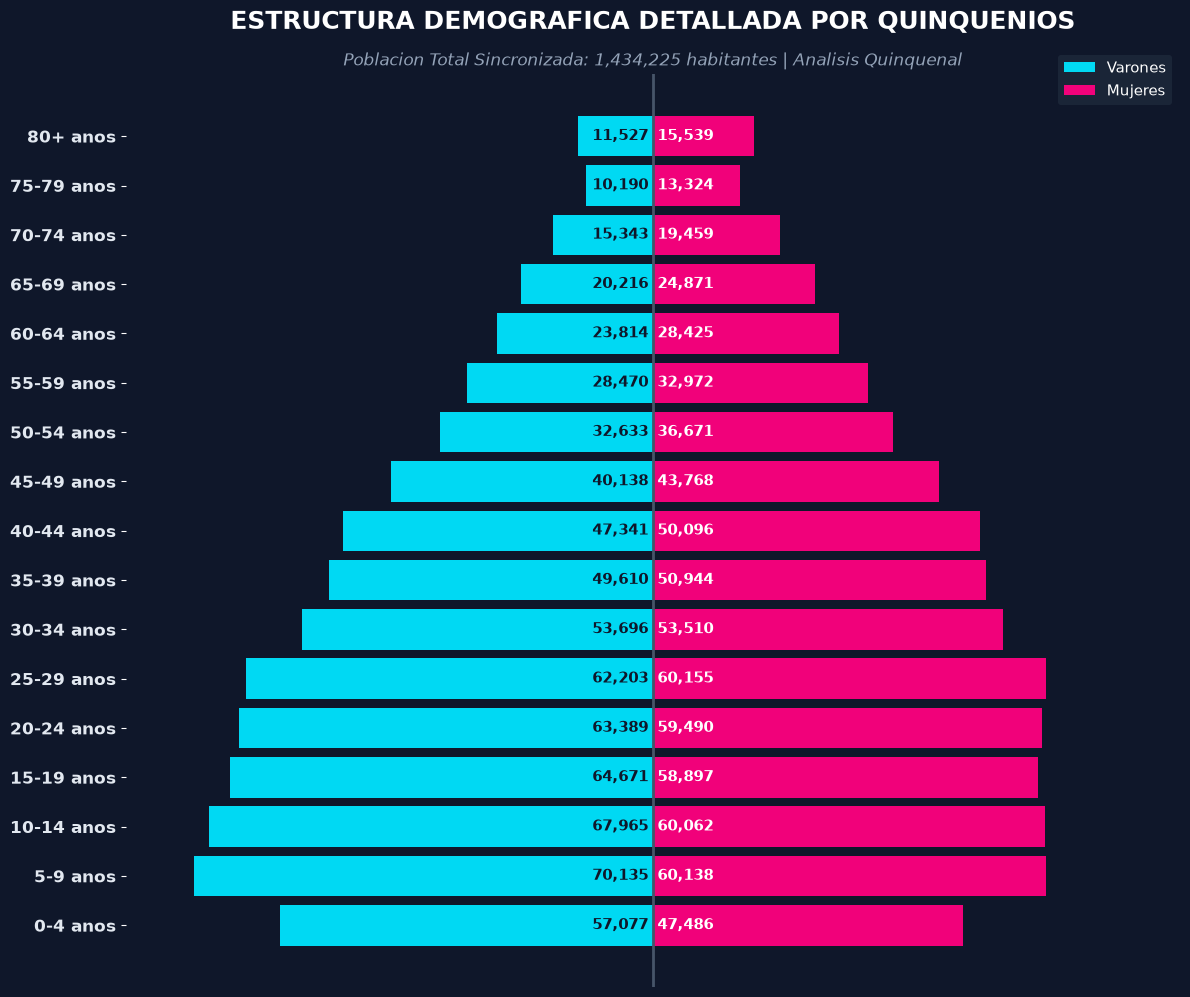

In [18]:
plot_data = age_distribution.copy()

varones_raw = plot_data["varones"].astype(int).tolist()
mujeres_raw = plot_data["mujeres"].astype(int).tolist()
grupos = plot_data["grupo_etario"].tolist()

total_pob_real = sum(varones_raw) + sum(mujeres_raw)

varones_pct = [(v / total_pob_real) * 100 for v in varones_raw]
mujeres_pct = [(m / total_pob_real) * 100 for m in mujeres_raw]
y_pos = np.arange(len(grupos))

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0F172A')
ax.set_facecolor('#0F172A')

COLOR_VARONES = '#00E5FF'
COLOR_MUJERES = '#FF007F'

max_pct = max(max(varones_pct), max(mujeres_pct))
ax.barh(y_pos, [-v for v in varones_pct], height=0.82, color=COLOR_VARONES, label='Varones', alpha=0.95)
ax.barh(y_pos, mujeres_pct, height=0.82, color=COLOR_MUJERES, label='Mujeres', alpha=0.95)

ax.set_xlim(-max_pct * 1.15, max_pct * 1.15)
ax.get_xaxis().set_visible(False)

ax.set_yticks(y_pos)
ax.set_yticklabels(grupos, fontsize=12, fontweight='bold', color='#E2E8F0')

offset_centro = max_pct * 0.01

for i, (v_pct, m_pct, v_num, m_num) in enumerate(zip(varones_pct, mujeres_pct, varones_raw, mujeres_raw)):
    ax.text(-offset_centro, i, f'{v_num:,}', ha='right', va='center',
            fontsize=10.5, color='#0F172A', fontweight='bold')

    ax.text(offset_centro, i, f'{m_num:,}', ha='left', va='center',
            fontsize=10.5, color='#FFFFFF', fontweight='bold')

ax.axvline(x=0, color='#475569', linewidth=2)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.text(0.5, 1.05, 'ESTRUCTURA DEMOGRAFICA DETALLADA POR QUINQUENIOS',
         transform=ax.transAxes, fontsize=18, fontweight='bold', ha='center', color='#FFFFFF')
plt.text(0.5, 1.01, f'Poblacion Total Sincronizada: {total_pob_real:,} habitantes | Analisis Quinquenal',
         transform=ax.transAxes, fontsize=12, style='italic', ha='center', color='#94A3B8')

ax.legend(loc='upper right', bbox_to_anchor=(1, 1.03), fontsize=11, frameon=True, facecolor='#1E293B', edgecolor='none')

plt.tight_layout()
plt.show()

## 16. Carga del modelo transformado en PostgreSQL

La etapa final del proyecto consiste en llevar los datos previamente explorados, limpiados y transformados a una base de datos PostgreSQL. El objetivo es conservar en la base de datos un modelo estructurado, reproducible y preparado para consultas analiticas.

La conexion se realiza mediante variables de entorno para evitar exponer credenciales en el notebook. La carga se ejecuta sobre las tablas finales generadas durante el proceso de transformacion.

In [21]:
if LOAD_POSTGRES and engine is not None:
    tables_to_load = {
        "dim_geografia": df_geo,
        "dim_variables": df_variables,
        "dim_categorias": df_categorias,
        "fact_hogar": df_hogar_h,
        "fact_persona": df_persona_h,
        "fact_vivienda": df_vivienda_h,
    }

    for table_name, dataframe in tables_to_load.items():
        dataframe.to_sql(
            table_name,
            engine,
            if_exists="replace",
            index=False,
            method="multi",
        )

    if "geometry" not in gdf_radios.columns:
        raise ValueError("La capa de radios no contiene una columna geometrica.")

    if gdf_radios.crs is None:
        raise ValueError("La capa de radios no tiene CRS definido.")

    gdf_radios_db = gdf_radios.copy()

    gdf_radios_db.to_postgis(
        "geo_radios_2022",
        engine,
        schema="public",
        if_exists="replace",
        index=False,
        chunksize=1000,
    )


In [22]:
if LOAD_POSTGRES and engine is not None:
    with engine.connect() as connection:
        tables = connection.execute(
            text(
                """
                SELECT table_name
                FROM information_schema.tables
                WHERE table_schema = 'public'
                ORDER BY table_name
                """
            )
        ).scalars().all()

        postgis_version = connection.execute(
            text("SELECT PostGIS_Version()")
        ).scalar_one()

        spatial_metadata = connection.execute(
            text(
                """
                SELECT
                    COUNT(*) AS registros,
                    COUNT(geometry) AS geometries,
                    ST_GeometryType(geometry) AS tipo_geometria,
                    ST_SRID(geometry) AS srid,
                    ST_IsValid(geometry) AS geometria_valida
                FROM public.geo_radios_2022
                GROUP BY ST_GeometryType(geometry), ST_SRID(geometry), ST_IsValid(geometry)
                ORDER BY registros DESC
                """
            )
        ).mappings().all()

    display(tables)
    display(pd.DataFrame([{"postgis_version": postgis_version}]))
    display(pd.DataFrame(spatial_metadata))


['dim_categorias',
 'dim_geografia',
 'dim_variables',
 'fact_hogar',
 'fact_persona',
 'fact_vivienda',
 'geo_radios_2022',
 'geography_columns',
 'geometry_columns',
 'spatial_ref_sys']

,postgis_version
0,3.6 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


,registros,geometries,tipo_geometria,srid,geometria_valida
0,1404,1404,ST_MultiPolygon,4326,True


### 16.1. Validacion de la carga

La validacion compara el numero de registros de los DataFrames originales con las filas almacenadas en PostgreSQL. Esto permite detectar perdidas durante la transferencia y comprobar que la base representa el resultado de la transformacion.

In [23]:
if LOAD_POSTGRES and engine is not None:
    validation = []

    with engine.connect() as connection:
        for table_name, dataframe in tables_to_load.items():
            db_count = connection.execute(
                text(f'SELECT COUNT(*) FROM "{table_name}"')
            ).scalar_one()

            validation.append(
                {
                    "tabla": table_name,
                    "registros_dataframe": len(dataframe),
                    "registros_postgres": db_count,
                    "coincide": len(dataframe) == db_count,
                }
            )

        spatial_count = connection.execute(
            text("SELECT COUNT(*) FROM public.geo_radios_2022")
        ).scalar_one()

        spatial_geometry_count = connection.execute(
            text(
                """
                SELECT COUNT(*)
                FROM public.geo_radios_2022
                WHERE geometry IS NOT NULL
                """
            )
        ).scalar_one()

        spatial_invalid_count = connection.execute(
            text(
                """
                SELECT COUNT(*)
                FROM public.geo_radios_2022
                WHERE geometry IS NOT NULL
                  AND NOT ST_IsValid(geometry)
                """
            )
        ).scalar_one()

        spatial_srid = connection.execute(
            text(
                """
                SELECT DISTINCT ST_SRID(geometry)
                FROM public.geo_radios_2022
                WHERE geometry IS NOT NULL
                """
            )
        ).scalars().all()

    validation.append(
        {
            "tabla": "geo_radios_2022",
            "registros_dataframe": len(gdf_radios_db),
            "registros_postgres": spatial_count,
            "coincide": len(gdf_radios_db) == spatial_count,
        }
    )

    validation_df = pd.DataFrame(validation)
    display(validation_df)

    assert validation_df["coincide"].all(), (
        "La cantidad de registros del DataFrame y PostgreSQL no coincide."
    )

    spatial_validation = pd.Series(
        {
            "registros_fuente": len(gdf_radios_db),
            "registros_postgres": int(spatial_count),
            "geometrias_cargadas": int(spatial_geometry_count),
            "geometrias_invalidas": int(spatial_invalid_count),
            "srid_postgres": ", ".join(map(str, spatial_srid)),
        },
        name="valor",
    )

    display(spatial_validation)

    assert spatial_count == len(gdf_radios_db)
    assert spatial_geometry_count == len(gdf_radios_db)
    assert spatial_invalid_count == 0
    assert spatial_srid == [4326], (
        f"Se esperaba SRID 4326 y se obtuvo: {spatial_srid}"
    )


,tabla,registros_dataframe,registros_postgres,coincide
0,dim_geografia,1829,1829,True
1,dim_variables,76,76,True
2,dim_categorias,1102,1102,True
3,fact_hogar,209096,209096,True
4,fact_persona,567706,567706,True
5,fact_vivienda,61354,61354,True
6,geo_radios_2022,1404,1404,True


registros_fuente        1404
registros_postgres      1404
geometrias_cargadas     1404
geometrias_invalidas       0
srid_postgres           4326
Name: valor, dtype: object

### 16.2. Consulta espacial desde PostgreSQL

La capa de radios se consulta directamente desde PostGIS. La consulta verifica que la geometria se encuentre almacenada como objeto espacial y permite recuperar atributos territoriales junto con su geometria.

In [24]:
if LOAD_POSTGRES and engine is not None:
    spatial_query = """
        SELECT
            codigo,
            departamento,
            fraccion,
            radio,
            ST_GeometryType(geometry) AS tipo_geometria,
            ST_SRID(geometry) AS srid,
            ST_AsText(ST_PointOnSurface(geometry)) AS punto_referencia
        FROM public.geo_radios_2022
        ORDER BY codigo
        LIMIT 5
    """

    spatial_sample = pd.read_sql(spatial_query, engine)
    display(spatial_sample)


,codigo,departamento,fraccion,radio,tipo_geometria,srid,punto_referencia
0,660070106,Anta,01,06,ST_MultiPolygon,4326,POINT(-63.99518145431516 -24.224722902758312)
1,660070107,Anta,01,07,ST_MultiPolygon,4326,POINT(-63.98796034360991 -24.223990105884212)
2,660070108,Anta,01,08,ST_MultiPolygon,4326,POINT(-63.98535279952556 -24.22864727274841)
3,660070109,Anta,01,09,ST_MultiPolygon,4326,POINT(-63.98683328880212 -24.232210520073437)
4,660070110,Anta,01,10,ST_MultiPolygon,4326,POINT(-63.99495895802784 -24.23047683540655)


### 16.3. Consulta analitica desde PostgreSQL

Una vez cargado el modelo, las consultas dejan de depender exclusivamente de los DataFrames de Python. La siguiente consulta recupera informacion directamente desde PostgreSQL para comprobar que la base puede utilizarse como capa analitica independiente del proceso de transformacion.

In [25]:
if LOAD_POSTGRES and engine is not None:
    population_query = """
        SELECT SUM(fp.cantidad) AS poblacion
        FROM fact_persona fp
        JOIN dim_categorias dc ON fp.id_categoria = dc.id_categoria
        JOIN dim_variables dv ON dc.id_variable = dv.id_variable
        WHERE dv.cod_variable = 'PERSONA_P02';
    """

    population_db = pd.read_sql(population_query, engine)["poblacion"].iloc[0]
    assert int(population_db) == EXPECTED_POPULATION

    department_query = """
        SELECT
            dg.departamento,
            SUM(fp.cantidad) AS poblacion,
            COUNT(DISTINCT dg.codigo) AS radios
        FROM fact_persona fp
        JOIN dim_categorias dc ON fp.id_categoria = dc.id_categoria
        JOIN dim_variables dv ON dc.id_variable = dv.id_variable
        JOIN dim_geografia dg ON fp.codigo = dg.codigo
        WHERE dv.cod_variable = 'PERSONA_P02'
        GROUP BY dg.departamento
        ORDER BY poblacion DESC;
    """

    department_db = pd.read_sql(department_query, engine)
    department_db["habitantes_por_radio"] = (
        department_db["poblacion"] / department_db["radios"]
    )

    display(department_db.head(10))

,departamento,poblacion,radios,habitantes_por_radio
0,Capital,"624,003.00",642,971.97
1,General Jose de San Martin,"177,448.00",212,837.02
2,Oran,"159,715.00",174,917.90
3,Anta,"69,442.00",120,578.68
4,General Guemes,"55,746.00",72,774.25
5,Cerrillos,"55,713.00",60,928.55
6,Rosario de Lerma,"50,961.00",81,629.15
7,Metan,"48,028.00",64,750.44
8,Rivadavia,"38,062.00",64,594.72
9,Rosario de la Frontera,"33,750.00",62,544.35


### 16.4 Visualización de la distribución poblacional departamental

El gráfico de barras horizontales representa la participación porcentual relativa de cada jurisdicción sobre el total general de la población provincial relevada. 

Esta normalización permite corregir la distorsión de escala provocada por la alta concentración macrocefálica en el departamento Capital, facilitando una comparación visual armónica, precisa y directa del peso demográfico real entre todas las jurisdicciones del interior de la provincia.

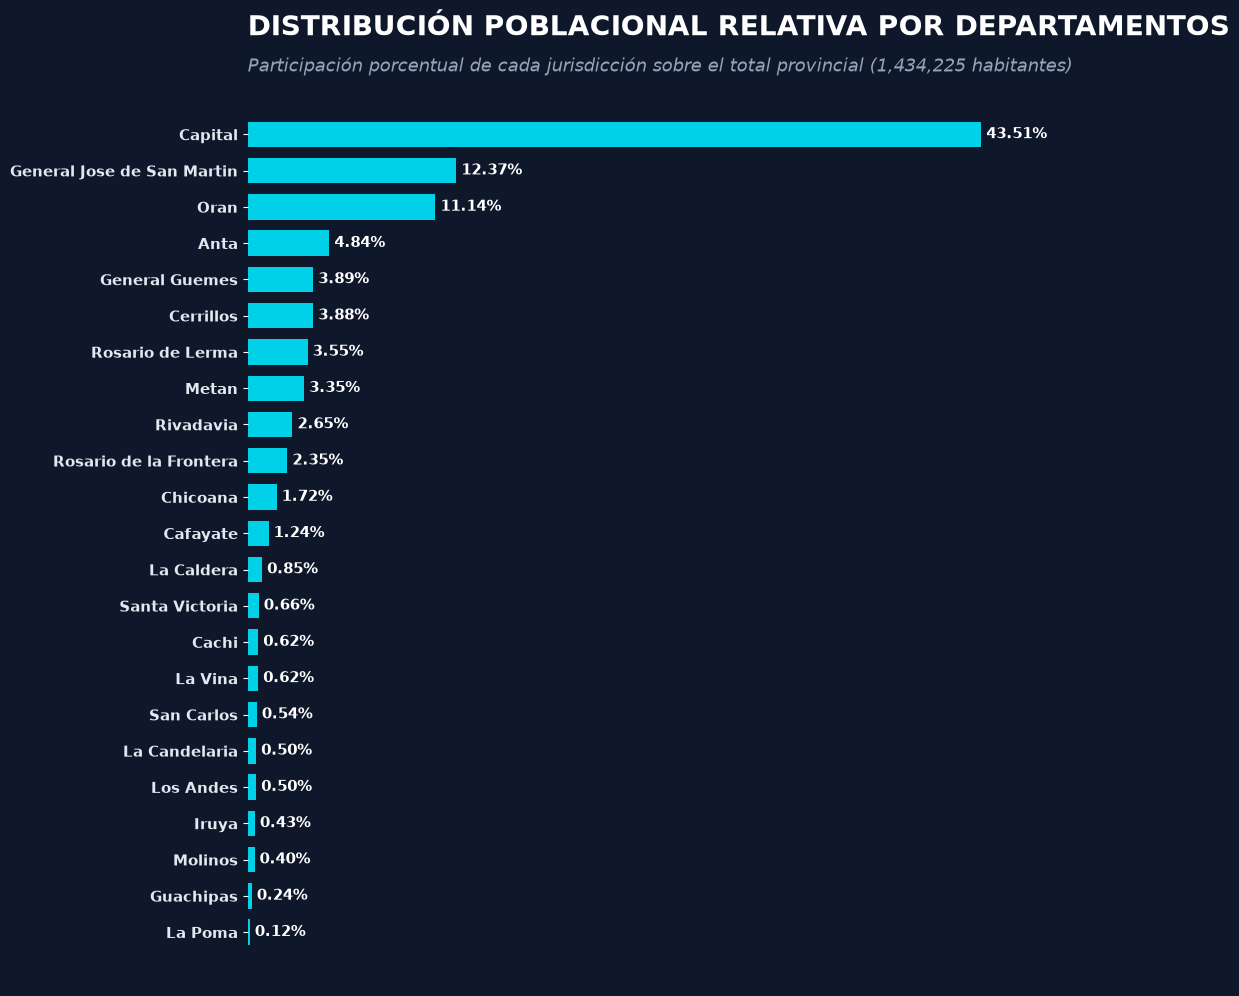

In [26]:
todos_deptos = department_db.copy()
total_provincial = todos_deptos['poblacion'].sum()
todos_deptos['porcentaje'] = (todos_deptos['poblacion'] / total_provincial) * 100
todos_deptos = todos_deptos.iloc[::-1]

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0F172A')
ax.set_facecolor('#0F172A')

y_pos = np.arange(len(todos_deptos))
barras = ax.barh(y_pos, todos_deptos['porcentaje'], height=0.70, 
                    color='#00E5FF', alpha=0.9, edgecolor='none')

ax.set_yticks(y_pos)
ax.set_yticklabels(todos_deptos['departamento'], fontsize=11, fontweight='bold', color='#E2E8F0')
ax.get_xaxis().set_visible(False)

max_pct = todos_deptos['porcentaje'].max()
ax.set_xlim(0, max_pct * 1.20)

for i, barra in enumerate(barras):
    pct_val = todos_deptos.iloc[i]['porcentaje']
    texto_etiqueta = f' {pct_val:.2f}%'
    ax.text(barra.get_width(), barra.get_y() + barra.get_height()/2, texto_etiqueta,
            va='center', ha='left', fontsize=10.5, color='#FFFFFF', fontweight='bold')
    
for spine in ax.spines.values():
    spine.set_visible(False)
    
ax.grid(axis='x', linestyle=':', alpha=0.1, color='#94A3B8')

plt.text(0.0, 1.05, 'DISTRIBUCIÓN POBLACIONAL RELATIVA POR DEPARTAMENTOS', 
            transform=ax.transAxes, fontsize=20, fontweight='bold', ha='left', color='#FFFFFF')
plt.text(0.0, 1.01, f'Participación porcentual de cada jurisdicción sobre el total provincial ({round(total_provincial):,} habitantes)', 
            transform=ax.transAxes, fontsize=13, style='italic', ha='left', color='#94A3B8')

plt.tight_layout()
plt.show()

### 16.5 Análisis de capital profesional por jurisdicción

Para evaluar la distribución de profesionales graduados sin sesgos por densidad demográfica, se diseñó una consulta basada en Expresiones de Tabla Comunes (CTEs) que extrae y unifica dos dimensiones independientes de la tabla de hechos `fact_persona`:

*   **`total_depto`:** Consolida de forma absoluta la cantidad total de habitantes censados por departamento mediante el filtro de la variable de control por sexo (`PERSONA_P02`).
*   **`uni_depto`:** Filtra de manera estricta los registros correspondientes al máximo nivel educativo alcanzado y terminado, cruzando la variable de máximo nivel de instrucción (`PERSONA_MNI`) con el código de categoría académica establecido (`cod_categoria = 9`).

Ambas estructuras se combinan mediante un `LEFT JOIN` con el fin de resguardar la integridad del set de datos, asegurando la inclusión de aquellas jurisdicciones que pudiesen registrar un conteo nulo de profesionales. Finalmente, el cálculo de la tasa porcentual relativa se realiza de forma dinámica en la capa de procesamiento de Pandas.


In [27]:
query_educacion = """
    WITH total_depto AS (
        SELECT 
            dg.departamento,
            SUM(fp.cantidad) AS poblacion_total
        FROM fact_persona fp
        JOIN dim_categorias dc ON fp.id_categoria = dc.id_categoria
        JOIN dim_variables dv ON dc.id_variable = dv.id_variable
        JOIN dim_geografia dg ON fp.codigo = dg.codigo
        WHERE dv.cod_variable = 'PERSONA_P02'
        GROUP BY dg.departamento
    ),
    uni_depto AS (
        SELECT 
            dg.departamento,
            SUM(fp.cantidad) AS universitarios_completos
        FROM fact_persona fp
        JOIN dim_categorias dc ON fp.id_categoria = dc.id_categoria
        JOIN dim_variables dv ON dc.id_variable = dv.id_variable
        JOIN dim_geografia dg ON fp.codigo = dg.codigo
        WHERE dv.cod_variable = 'PERSONA_MNI' AND dc.cod_categoria = 9
        GROUP BY dg.departamento
    )
    SELECT 
        td.departamento,
        td.poblacion_total,
        COALESCE(ud.universitarios_completos, 0) AS universitarios
    FROM total_depto td
    LEFT JOIN uni_depto ud ON td.departamento = ud.departamento
    ORDER BY td.poblacion_total DESC;
"""

df_edu = pd.read_sql(query_educacion, engine)

df_edu['tasa_universitaria'] = (df_edu['universitarios'] / df_edu['poblacion_total']) * 100

df_edu = df_edu.sort_values(by='tasa_universitaria', ascending=False)
df_edu

,departamento,poblacion_total,universitarios,tasa_universitaria
12,La Caldera,"12,246.00",932.00,7.61
0,Capital,"624,003.00","30,022.00",4.81
7,Metan,"48,028.00","1,248.00",2.60
11,Cafayate,"17,822.00",434.00,2.44
6,Rosario de Lerma,"50,961.00","1,127.00",2.21
5,Cerrillos,"55,713.00","1,051.00",1.89
9,Rosario de la Frontera,"33,750.00",584.00,1.73
15,La Vina,"8,888.00",130.00,1.46
4,General Guemes,"55,746.00",769.00,1.38
1,General Jose de San Martin,"177,448.00","2,380.00",1.34


### 16.6 Visualización analítica

El gráfico de barras verticales representa la tasa de graduados universitarios por cada 100 habitantes, ordenando las jurisdicciones de mayor a menor impacto de densidad profesional.

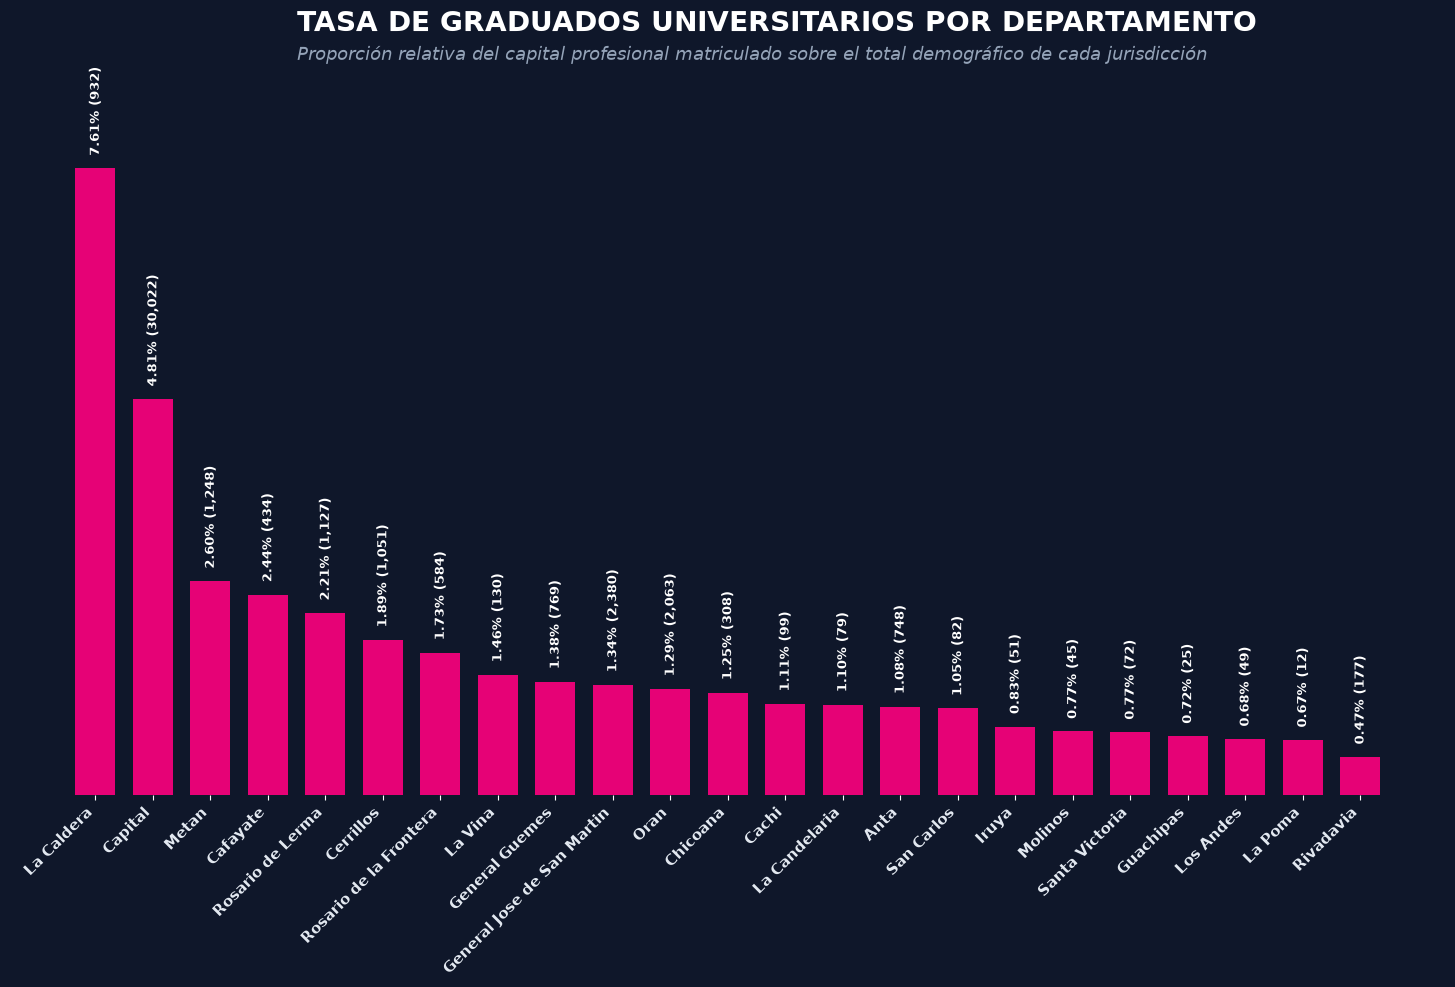

In [28]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 10), facecolor='#0F172A')
ax.set_facecolor('#0F172A')

x_pos = np.arange(len(df_edu))

barras = ax.bar(x_pos, df_edu['tasa_universitaria'], width=0.70, 
                color='#FF007F', alpha=0.9, edgecolor='none')

ax.set_xticks(x_pos)
ax.set_xticklabels(df_edu['departamento'], fontsize=11, fontweight='bold', 
                   color='#E2E8F0', rotation=45, ha='right')

ax.get_yaxis().set_visible(False)

max_tasa = df_edu['tasa_universitaria'].max()
ax.set_ylim(0, max_tasa * 1.15)

for barra, tasa_val, uni_num in zip(barras, df_edu['tasa_universitaria'], df_edu['universitarios']):
    texto_etiqueta = f'{tasa_val:.2f}% ({int(uni_num):,})'
    
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + (max_tasa * 0.02), 
            texto_etiqueta, va='bottom', ha='center', fontsize=9.5, 
            color='#FFFFFF', fontweight='bold', rotation=90)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis='y', linestyle=':', alpha=0.1, color='#94A3B8')

plt.text(0.2, 1.06, 'TASA DE GRADUADOS UNIVERSITARIOS POR DEPARTAMENTO', 
         transform=ax.transAxes, fontsize=20, fontweight='bold', ha='left', color='#FFFFFF')
plt.text(0.2, 1.02, f'Proporción relativa del capital profesional matriculado sobre el total demográfico de cada jurisdicción', 
         transform=ax.transAxes, fontsize=13, style='italic', ha='left', color='#94A3B8')

plt.tight_layout()
plt.show()

# 17. Cierre y productos generados

El flujo deja separados tres niveles de informacion:

- **datos observados:** tablas censales originales y agregaciones directas;
- **datos transformados:** dimensiones, tablas de hechos e integracion espacial;
- **datos derivados:** indicadores, mapas y distribucion por sexo estimada dentro de grupos etarios.

### Productos principales

- `censo_diseno_final/geografia.csv`
- `censo_diseno_final/variables.csv`
- `censo_diseno_final/categorias.csv`
- `censo_diseno_final/hogar.csv`
- `censo_diseno_final/persona.csv`
- `censo_diseno_final/vivienda.csv`
- `mapas_generados/mapa_poblacion_salta.html`
- `mapas_generados/mapa_universitarios_completos_salta.html`

Este diseno permite extender el proyecto hacia un pipeline ETL, un modelo analitico en PostgreSQL/PostGIS o un dashboard sin volver a procesar los archivos originales.